# Gap Matching — Roster Need Scorer

Computes how well a player's individual stat profile fills the specific statistical gaps in a school's current roster, position by position.

**Feature space:**

| Layer | Dims | Player source | Position weight source |
|---|---|---|---|
| Stat profile | 8 | `player_season_stats` (ppg, rpg, apg, spg, bpg, ts%, usage%, 3pt rate) | — |
| Position weights | 5 (soft) | `hoop_explorer_player_stats.pos_confidence_*` (59.3% coverage) | one-hot `players.position` fallback (40.7%) |

`gap_match` in DB = soft-weighted cosine similarity between a player's scaled stat vector and a school's position-specific gap vector (`max(0, league_benchmark - roster_mean)`), summed across positions using the player's position-confidence weights.

**Output:** `player_team_fit_scores.gap_match` — same player×school×season pairs already scored by Model 3 (no new pairs added).

**Prerequisites:**
- `scheme_fit_scorer.ipynb` complete → `player_team_fit_scores` populated (defines pair scope)
- `player_clustering.ipynb` complete → `player_archetypes` populated (archetype deficit flag)
- `player_season_stats` + `hoop_explorer_player_stats` populated in DB

**Known limitations (see Cell 0 for detail):**
- `transfers` table is empty — no departure filter; roster = everyone in `player_season_stats` for that school/season
- `player_school_seasons` is empty — roster source is `player_season_stats.school_id`
- `breakdown.gap.uniqueness_bonus` / `redundancy_penalty` not yet computed — API placeholders until a v2 adds them

In [2]:
# Cell 0 — Imports + Config
import os, json, warnings
from pathlib import Path
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import psycopg2
from psycopg2.extras import execute_values
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

# ── paths ────────────────────────────────────────────────────────────────────
ROOT       = Path(os.getcwd()).parent.parent
MODELS_DIR = ROOT / 'data' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── config ───────────────────────────────────────────────────────────────────
SEASONS_IN_DATA = [2021, 2022, 2023, 2024, 2025, 2026]
CURRENT_SEASON  = max(SEASONS_IN_DATA)

GAP_FEATURES = [
    'points_per_game', 'rebounds_per_game', 'assists_per_game',
    'steals_per_game',  'blocks_per_game',  'true_shooting_pct',
    'usage_rate',       'three_point_rate',
]
POS_COLS  = ['pos_confidence_pg', 'pos_confidence_sg', 'pos_confidence_sf',
             'pos_confidence_pf', 'pos_confidence_c']
POS_NAMES = ['PG', 'SG', 'SF', 'PF', 'C']
POS_IDX   = {p: i for i, p in enumerate(POS_NAMES)}

MIN_GAMES     = 5
MODEL_VERSION = 'gap-cos-v1'
W_GAP    = 0.20
W_SCHEME = 0.30
W_ROLE   = 0.25
W_PROG   = 0.25

# ── KNOWN LIMITATIONS ────────────────────────────────────────────────────────
# transfers table: 0 rows — no departure filter applied; gap computed against
#   full season roster (not adjusted for players who left before season end).
# player_school_seasons: 0 rows — roster source is player_season_stats.school_id.
# Both will improve accuracy when VerbalCommits data is ingested.

print('Config loaded — seasons:', SEASONS_IN_DATA)

Config loaded — seasons: [2021, 2022, 2023, 2024, 2025, 2026]


## 1. Load Player Stats

Pulls 8-dim stat vectors from `player_season_stats`, joined to `players.position` and LEFT JOINed to `hoop_explorer_player_stats` for soft position confidence. Filters to `games_played >= MIN_GAMES` and all 8 features non-null. Deduplicated to one row per `(player_id, season)` — mid-season transfers keep the row with more games played.

In [3]:
# Cell 1 — DB connect + load player stats with soft position weights
# Joins player_season_stats + players + LEFT JOIN hoop_explorer_player_stats.
# HE coverage: ~59% of rows. Remaining 41% get one-hot fallback in Cell 2.
DB_URL = os.environ['DATABASE_URL'].replace('postgresql+asyncpg://', 'postgresql://')
conn   = psycopg2.connect(DB_URL)

LOAD_SQL = f"""
SELECT
    pss.player_id,
    pss.school_id,
    pss.season,
    pss.games_played,
    p.position,
    pss.points_per_game,
    pss.rebounds_per_game,
    pss.assists_per_game,
    pss.steals_per_game,
    pss.blocks_per_game,
    pss.true_shooting_pct,
    pss.usage_rate,
    pss.three_point_rate,
    hep.pos_confidence_pg,
    hep.pos_confidence_sg,
    hep.pos_confidence_sf,
    hep.pos_confidence_pf,
    hep.pos_confidence_c
FROM player_season_stats pss
JOIN players p ON p.id = pss.player_id
LEFT JOIN hoop_explorer_player_stats hep
    ON hep.player_id = pss.player_id AND hep.season = pss.season
WHERE pss.games_played           >= {MIN_GAMES}
  AND pss.points_per_game        IS NOT NULL
  AND pss.rebounds_per_game      IS NOT NULL
  AND pss.assists_per_game       IS NOT NULL
  AND pss.steals_per_game        IS NOT NULL
  AND pss.blocks_per_game        IS NOT NULL
  AND pss.true_shooting_pct      IS NOT NULL
  AND pss.usage_rate             IS NOT NULL
  AND pss.three_point_rate       IS NOT NULL
"""

with conn.cursor() as cur:
    cur.execute(LOAD_SQL)
    cols = [d[0] for d in cur.description]
    df   = pd.DataFrame(cur.fetchall(), columns=cols)

# Dedup: keep row with most games_played per (player_id, season)
df = (
    df.sort_values('games_played', ascending=False)
      .drop_duplicates(subset=['player_id', 'season'], keep='first')
      .reset_index(drop=True)
)

he_cov = df[POS_COLS].notna().all(axis=1).sum()
print(f'Loaded {len(df):,} player-season rows')
print(f'HE pos_confidence coverage: {he_cov:,}/{len(df):,} ({100*he_cov/len(df):.1f}%)')
print('\nRows per season:')
print(df['season'].value_counts().sort_index())

Loaded 26,862 player-season rows
HE pos_confidence coverage: 16,036/26,862 (59.7%)

Rows per season:
season
2021    4239
2022    4504
2023    4521
2024    4532
2025    4541
2026    4525
Name: count, dtype: int64


## 2. Soft Position Assignment

HE `pos_confidence_pg/sg/sf/pf/c` already sums to ~1.0 and is used directly where available (~59% of rows). The remaining ~41% (no HE match) fall back to a one-hot vector from `players.position`. Both paths are renormalized to guard against rounding drift or rows with no position data at all.

In [4]:
# Cell 2 — Soft position weights
# For ~41% of rows without HE data, fall back to one-hot from players.position.
# pos_confidence already sums to ~1.0 for HE rows (validated in DB audit).
mask_no_he = df[POS_COLS].isna().all(axis=1)
print(f'Rows using one-hot fallback (no HE match): {mask_no_he.sum():,}')
print(f'Position breakdown of fallback rows:')
print(df[mask_no_he]['position'].value_counts())

for pos_name, pos_col in zip(POS_NAMES, POS_COLS):
    df.loc[mask_no_he & (df['position'] == pos_name), pos_col] = 1.0

# Zero-fill any remaining NaN (edge case: player with unknown position and no HE)
df[POS_COLS] = df[POS_COLS].fillna(0.0)

# Renormalize to sum=1 (guards against any rounding drift)
row_sums = df[POS_COLS].sum(axis=1).clip(lower=1e-9)
df[POS_COLS] = df[POS_COLS].div(row_sums, axis=0)

# Flag zero-sum rows (player with no position data at all)
zero_weight = (df[POS_COLS].sum(axis=1) < 0.01).sum()
if zero_weight > 0:
    print(f'WARNING: {zero_weight} rows with zero position weights — will score as 0')

print('\npos_confidence sum stats after normalization:')
print(df[POS_COLS].sum(axis=1).describe().round(4))

Rows using one-hot fallback (no HE match): 10,826
Position breakdown of fallback rows:
position
G    10826
Name: count, dtype: int64

pos_confidence sum stats after normalization:
count    26862.0000
mean         0.5970
std          0.4905
min          0.0000
25%          0.0000
50%          1.0000
75%          1.0000
max          1.0000
dtype: float64


## 3. League Benchmarks

For each season and position, computes the soft-weighted mean stat vector across all players — i.e. "what does an average PG/SG/SF/PF/C look like this season." This is the target every school's roster is compared against per position.

In [5]:
# Cell 3 — League benchmarks per season × position (soft-weighted)
# benchmark[season] = np.ndarray (5, 8): mean stat vector per position across all players,
# weighted by each player's pos_confidence for that position.
benchmarks = {}

for season in SEASONS_IN_DATA:
    s      = df[df['season'] == season]
    B      = np.zeros((5, len(GAP_FEATURES)))
    stats  = s[GAP_FEATURES].values.astype(float)   # n × 8
    for p_i, pos_col in enumerate(POS_COLS):
        w     = s[pos_col].values                    # n,
        w_sum = w.sum()
        if w_sum > 0:
            B[p_i] = (w[:, None] * stats).sum(axis=0) / w_sum
        else:
            B[p_i] = stats.mean(axis=0)
    benchmarks[season] = B

bench_df = pd.DataFrame(
    benchmarks[CURRENT_SEASON],
    index=POS_NAMES,
    columns=GAP_FEATURES,
).round(2)
print(f'League benchmark ({CURRENT_SEASON}) — weighted mean stats per position:')
print(bench_df.to_string())

League benchmark (2026) — weighted mean stats per position:
    points_per_game  rebounds_per_game  assists_per_game  steals_per_game  blocks_per_game  true_shooting_pct  usage_rate  three_point_rate
PG            10.10               2.74              2.19             0.55             0.14              52.77       21.09              0.43
SG             9.58               3.04              2.36             0.68             0.21              53.82       19.39              0.50
SF             9.21               4.18              2.98             1.21             0.37              54.94       19.35              0.39
PF             8.74               4.69              3.28             1.41             0.55              55.39       19.12              0.40
C              7.32               5.14              3.18             1.97             0.96              58.74       17.97              0.04


## 4. Roster Gap Vectors

For each school × season × position, computes the soft-weighted mean stat vector of players currently on that roster, then takes `max(0, benchmark - roster_mean)`. The result is a **sparse, non-negative gap vector**: zero where the school is already at or above league average for that stat, positive where the school is short. This sparsity is intentional — it is what makes `gap_match` discriminate much more sharply than `scheme_fit` (see Section 8).

Also tracks `depth` (effective player-equivalents) per position for the `position_depth_score` breakdown field.

In [6]:
# Cell 4 — Roster composition + gap vectors per school × season × position
# gap_data[season][school_id] = {
#   'gap_vecs': np.ndarray (5, 8)  — max(0, benchmark - roster_mean) per position
#   'depth':    np.ndarray (5,)    — effective player-equivalents per position
# }
# Roster for school X in season S = all players with pss.school_id = X AND pss.season = S.
# KNOWN LIMITATION: transfers table is empty — no departure adjustment.

gap_data = {}

for season in SEASONS_IN_DATA:
    s_df     = df[df['season'] == season]
    B        = benchmarks[season]              # (5, 8)
    schools  = s_df['school_id'].unique()
    season_d = {}

    for sid in schools:
        g       = s_df[s_df['school_id'] == sid]
        stats   = g[GAP_FEATURES].values.astype(float)   # n_roster × 8
        weights = g[POS_COLS].values.astype(float)        # n_roster × 5

        roster_mean = np.zeros((5, 8))
        depth       = np.zeros(5)

        for p_i in range(5):
            w     = weights[:, p_i]
            w_sum = w.sum()
            depth[p_i] = w_sum
            if w_sum > 0:
                roster_mean[p_i] = (w[:, None] * stats).sum(axis=0) / w_sum
            else:
                # Position entirely missing — full benchmark is the gap
                roster_mean[p_i] = np.zeros(len(GAP_FEATURES))

        gap_vecs = np.maximum(0.0, B - roster_mean)      # (5, 8)
        season_d[int(sid)] = {'gap_vecs': gap_vecs, 'depth': depth}

    gap_data[season] = season_d
    print(f'Season {season}: gap vectors built for {len(season_d)} schools')

# Spot check: current season, first school — print gap by position
sample_sid = list(gap_data[CURRENT_SEASON].keys())[0]
sample_gv  = gap_data[CURRENT_SEASON][sample_sid]['gap_vecs']
print(f'\nSample gap vectors (school_id={sample_sid}, season={CURRENT_SEASON}):')
print(pd.DataFrame(sample_gv, index=POS_NAMES, columns=GAP_FEATURES).round(2))

Season 2021: gap vectors built for 346 schools
Season 2022: gap vectors built for 358 schools
Season 2023: gap vectors built for 363 schools
Season 2024: gap vectors built for 362 schools
Season 2025: gap vectors built for 364 schools
Season 2026: gap vectors built for 365 schools

Sample gap vectors (school_id=22, season=2026):
    points_per_game  rebounds_per_game  assists_per_game  steals_per_game  \
PG             0.53               0.27              0.03             0.24   
SG             1.07               0.15              0.07             0.08   
SF             0.05               0.33              0.11             0.22   
PF             0.00               0.00              0.00             0.04   
C              0.00               0.00              0.00             0.00   

    blocks_per_game  true_shooting_pct  usage_rate  three_point_rate  
PG              0.0                0.0        0.00               0.0  
SG              0.0                0.0        1.61              

## 5. Archetype Enrichment

Pulls Model 1 (`player_archetypes`) cluster assignments and flags, per school × season, the top-2 archetype clusters the school is most under-represented in vs. league average. A player whose archetype matches one of those deficit clusters gets `archetype_needed=True` in the breakdown — a categorical signal alongside the continuous `gap_match` score.

In [7]:
# Cell 5 — Archetype enrichment
# Uses archetype_id (integer cluster index) for numeric ops,
# archetype_label (string) for display only.

conn.rollback()

ARCH_SQL = 'SELECT player_id, season, archetype_id, archetype_label FROM player_archetypes'
with conn.cursor() as cur:
    cur.execute(ARCH_SQL)
    arch_df = pd.DataFrame(cur.fetchall(), columns=['player_id', 'season', 'archetype_id', 'archetype_label'])

print(f'Loaded {len(arch_df):,} player_archetype rows')
print(f'Unique archetypes:\n{arch_df.groupby("archetype_id")["archetype_label"].first().sort_index()}')

df = df.merge(arch_df, on=['player_id', 'season'], how='left')
arch_cov = df['archetype_id'].notna().sum()
print(f'\nArchetype coverage: {arch_cov:,}/{len(df):,} ({100*arch_cov/len(df):.1f}%)')

N_CLUSTERS = int(df['archetype_id'].dropna().max()) + 1
print(f'N clusters (from M1): {N_CLUSTERS}')

# arch_deficit[season][school_id] = set of archetype_id values school is short on
arch_deficit = {}

for season in SEASONS_IN_DATA:
    s_df  = df[df['season'] == season]

    league_counts = s_df['archetype_id'].value_counts(normalize=True)
    league_dist   = np.zeros(N_CLUSTERS)
    for c, v in league_counts.items():
        if pd.notna(c):
            league_dist[int(c)] = v

    season_deficit = {}
    for sid in s_df['school_id'].unique():
        g             = s_df[s_df['school_id'] == sid]
        school_counts = g['archetype_id'].value_counts(normalize=True)
        school_dist   = np.zeros(N_CLUSTERS)
        for c, v in school_counts.items():
            if pd.notna(c):
                school_dist[int(c)] = v
        gap_arr  = league_dist - school_dist
        pos_gaps = np.where(gap_arr > 0)[0]
        deficit  = set(pos_gaps[np.argsort(gap_arr[pos_gaps])[-2:]]) if len(pos_gaps) > 0 else set()
        season_deficit[int(sid)] = deficit

    arch_deficit[season] = season_deficit

total_school_seasons = sum(len(v) for v in arch_deficit.values())
print(f'Archetype deficit computed for {total_school_seasons:,} school-seasons')

Loaded 18,769 player_archetype rows
Unique archetypes:
archetype_id
0      Lead Scoring Playmaker
1         High-Usage Frontcourt Creator
2          Skilled Stretch Forward
3     Post Scoring Big
4          Perimeter Scoring Guard
5     Pressure Connector Guard
6     Defensive Connector Forward
7    Movement Spacing Wing
8          Interior Star Big
Name: archetype_label, dtype: str

Archetype coverage: 18,769/26,862 (69.9%)
N clusters (from M1): 9
Archetype deficit computed for 2,158 school-seasons


## 6. Feature Scaling

Fits one `StandardScaler` on the full pooled player population (all seasons) and applies it identically to player stat vectors and gap vectors, so cosine similarity operates in a consistent, unit-variance space. Gap vectors are pre-scaled here once rather than per-pair.

In [8]:
# Cell 6 — Fit StandardScaler + pre-scale gap tensors
# Scaler fitted on full player population (all seasons pooled).
# Same scaler applied to both player stat vectors and gap vectors
# so cosine similarity is in a consistent space.

all_stats = df[GAP_FEATURES].values.astype(float)
scaler    = StandardScaler()
scaler.fit(all_stats)

print(f'Scaler fitted on {len(all_stats):,} player-season rows')
print('Feature means:', dict(zip(GAP_FEATURES, scaler.mean_.round(2))))

# Pre-scale gap tensors: gap_scaled[season][school_id] = (5, 8) scaled
gap_scaled = {}
for season in SEASONS_IN_DATA:
    season_scaled = {}
    for sid, d in gap_data[season].items():
        season_scaled[sid] = scaler.transform(d['gap_vecs'])   # (5, 8)
    gap_scaled[season] = season_scaled

print('Gap tensors scaled ✓')

Scaler fitted on 26,862 player-season rows
Feature means: {'points_per_game': np.float64(6.54), 'rebounds_per_game': np.float64(2.92), 'assists_per_game': np.float64(2.12), 'steals_per_game': np.float64(0.8), 'blocks_per_game': np.float64(0.3), 'true_shooting_pct': np.float64(51.07), 'usage_rate': np.float64(18.43), 'three_point_rate': np.float64(0.37)}
Gap tensors scaled ✓


## 7. Score All Pairs

Vectorized per season: builds `P` (players × 8), `G` (schools × 5 positions × 8), computes cosine similarity between every player and every (school, position) gap vector in one `cosine_similarity` call, then collapses the position axis with the player's soft position weights. Only pairs already present in `player_team_fit_scores` (from Model 3) are scored — Gap Matching does not expand the pair scope.

In [9]:
# Cell 7 — Load existing pairs + per-season scoring loop (vectorized)
#
# Scope: score exactly the player×school×season pairs that M3 wrote to
# player_team_fit_scores. We UPDATE gap_match on those rows (no new inserts).
#
# Vectorization:
#   P_s:  n_players × 8           (scaled player stats)
#   G_s:  n_schools × 5 × 8      (scaled gap vecs per position)
#   W_s:  n_players × 5          (pos_confidence soft weights)
#   SIM:  n_players × n_schools  (weighted cosine across positions)
#     = sum_over_pos( W[:, None, :] * cosine(P, G_flat).reshape(n_p, n_s, 5) )

EXISTING_SQL = """
SELECT player_id, school_id, season, scheme_fit, breakdown
FROM player_team_fit_scores
WHERE season = ANY(%s)
"""
with conn.cursor() as cur:
    cur.execute(EXISTING_SQL, (SEASONS_IN_DATA,))
    existing_rows = cur.fetchall()

existing = {
    (r[0], r[1], r[2]): {'scheme_fit': r[3], 'breakdown': r[4]}
    for r in existing_rows
}
print(f'Existing M3 pairs loaded: {len(existing):,}')

records  = []   # (player_id, school_id, season, gap_match, overall_fit, merged_breakdown)

def depth_score(depth_val: float) -> float:
    return float(np.clip(100.0 - depth_val * 20.0, 0.0, 100.0))

for season in SEASONS_IN_DATA:
    s_df     = df[df['season'] == season].reset_index(drop=True)
    sids     = sorted(gap_scaled[season].keys())
    n_p      = len(s_df)
    n_s      = len(sids)
    sid_to_i = {sid: i for i, sid in enumerate(sids)}

    P_s = scaler.transform(s_df[GAP_FEATURES].values.astype(float))   # n_p × 8
    W_s = s_df[POS_COLS].values.astype(float)                          # n_p × 5

    # Build gap tensor G_s: n_s × 5 × 8
    G_s    = np.stack([gap_scaled[season][sid] for sid in sids], axis=0)
    G_flat = G_s.reshape(n_s * 5, 8)                                   # (n_s*5) × 8

    # Full similarity: n_p × (n_s*5)  →  n_p × n_s × 5
    SIM_flat = cosine_similarity(P_s, G_flat)
    SIM      = SIM_flat.reshape(n_p, n_s, 5)

    # Weighted sum across positions → n_p × n_s
    GAP_MATRIX = np.clip((W_s[:, None, :] * SIM).sum(axis=2) * 100, 0.0, 100.0)

    now_ts = datetime.now(timezone.utc).isoformat()

    # Build player lookup: player_id → row index in s_df
    pid_to_i = {int(pid): i for i, pid in enumerate(s_df['player_id'])}

    # Iterate only over pairs that exist in player_team_fit_scores
    season_pairs = [(pid, sid) for (pid, sid, ssn) in existing if ssn == season]
    matched = 0
    for (pid, sid) in season_pairs:
        pi = pid_to_i.get(pid)
        si = sid_to_i.get(sid)
        if pi is None or si is None:
            # Player had data in M3 parquet but not in player_season_stats — skip
            continue

        gap_match = float(GAP_MATRIX[pi, si])
        row       = s_df.iloc[pi]
        arch_id   = row['archetype_id']
        cluster   = int(arch_id) if pd.notna(arch_id) else -1
        pos_w     = W_s[pi]                            # (5,)
        depth     = gap_data[season][sid]['depth']     # (5,)

        # Weighted depth score across positions
        pos_depth = float(np.sum(pos_w * np.array([depth_score(depth[p]) for p in range(5)])))

        archetype_needed = (
            cluster >= 0 and
            cluster in arch_deficit[season].get(sid, set())
        )

        # Merge with existing breakdown from M3
        ex         = existing.get((pid, sid, season), {})
        scheme_fit = float(ex.get('scheme_fit') or 0.0)
        ex_bd      = ex.get('breakdown') or {}
        if isinstance(ex_bd, str):
            ex_bd = json.loads(ex_bd)

        new_bd = {
            'gap': {
                'position_depth_score': round(pos_depth, 1),
                'archetype_needed':     archetype_needed,
            }
        }
        merged_bd = {**ex_bd, **new_bd}

        overall_fit = round(
            W_GAP * gap_match + W_SCHEME * scheme_fit +
            W_ROLE * 50.0     + W_PROG   * 50.0,
            2
        )

        records.append((
            pid, sid, season,
            gap_match, overall_fit,
            json.dumps(merged_bd),
            now_ts,
        ))
        matched += 1

    print(f'Season {season}: {matched:,} pairs scored (of {len(season_pairs):,} existing)')

print(f'\nTotal records to upsert: {len(records):,}')

Existing M3 pairs loaded: 1,343,050
Season 2021: 211,950 pairs scored (of 211,950 existing)
Season 2022: 225,150 pairs scored (of 225,150 existing)
Season 2023: 226,050 pairs scored (of 226,050 existing)
Season 2024: 226,600 pairs scored (of 226,600 existing)
Season 2025: 227,050 pairs scored (of 227,050 existing)
Season 2026: 226,250 pairs scored (of 226,250 existing)

Total records to upsert: 1,343,050


## 8. Validation

`gap_match` is expected to look very different from `scheme_fit`: low mean, high standard deviation, right-skewed. This is correct — most player×school pairs have low gap alignment (the player offers what the school already has), while high scores (80+) flag genuine, specific roster need. Compare `std` against `scheme_fit`'s `std` as the discrimination check, not the means.

=== Gap Match Score Distribution (all seasons) ===
count    1343050.00
mean           6.38
std           16.80
min            0.00
25%            0.00
50%            0.00
75%            0.00
max           98.20
Name: gap_match, dtype: float64


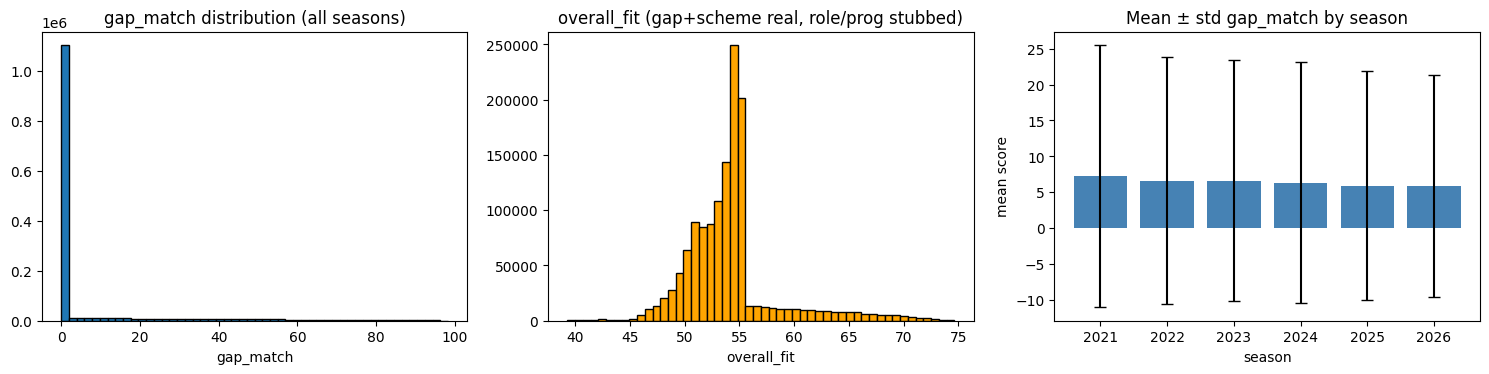


=== Per-season stats ===
        mean        std  min        max
season                                 
2021    7.23  18.340000  0.0  98.199997
2022    6.60  17.260000  0.0  98.089996
2023    6.55  16.830000  0.0  94.870003
2024    6.29  16.799999  0.0  98.070000
2025    5.86  15.980000  0.0  96.180000
2026    5.82  15.510000  0.0  94.199997

Top 5 schools by mean gap_match (2026):
school_id
17     11.85
9      11.31
36     11.24
114    11.11
267    10.70
Name: gap_match, dtype: float32

Score spread comparison (std):
  gap_match std:  16.80
  scheme_fit std: 7.22


In [10]:
# Cell 8 — Validation
# Build DataFrame column-by-column via numpy to bypass pandas nested_data_to_arrays OOM.
# records tuple: (player_id, school_id, season, gap_match, overall_fit, breakdown_json, now_ts)
rec_df = pd.DataFrame({
    'player_id':   np.array([r[0] for r in records], dtype=np.int32),
    'school_id':   np.array([r[1] for r in records], dtype=np.int32),
    'season':      np.array([r[2] for r in records], dtype=np.int16),
    'gap_match':   np.array([r[3] for r in records], dtype=np.float32),
    'overall_fit': np.array([r[4] for r in records], dtype=np.float32),
})

print('=== Gap Match Score Distribution (all seasons) ===')
print(rec_df['gap_match'].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rec_df['gap_match'], bins=50, edgecolor='black')
axes[0].set_title('gap_match distribution (all seasons)')
axes[0].set_xlabel('gap_match')

axes[1].hist(rec_df['overall_fit'], bins=50, edgecolor='black', color='orange')
axes[1].set_title('overall_fit (gap+scheme real, role/prog stubbed)')
axes[1].set_xlabel('overall_fit')

season_stats = rec_df.groupby('season')['gap_match'].agg(['mean', 'std'])
axes[2].bar(season_stats.index, season_stats['mean'], yerr=season_stats['std'],
            capsize=4, color='steelblue')
axes[2].set_title('Mean ± std gap_match by season')
axes[2].set_xlabel('season')
axes[2].set_ylabel('mean score')
plt.tight_layout()
plt.show()

print('\n=== Per-season stats ===')
print(rec_df.groupby('season')['gap_match'].agg(['mean', 'std', 'min', 'max']).round(2))

cur_df  = rec_df[rec_df['season'] == CURRENT_SEASON]
top_gap = cur_df.groupby('school_id')['gap_match'].mean().nlargest(5)
print(f'\nTop 5 schools by mean gap_match ({CURRENT_SEASON}):')
print(top_gap.round(2))

existing_df = pd.DataFrame({
    'scheme_fit': np.array([r[3] for r in existing_rows], dtype=np.float32),
})
print(f'\nScore spread comparison (std):')
print(f'  gap_match std:  {rec_df["gap_match"].std():.2f}')
print(f'  scheme_fit std: {existing_df["scheme_fit"].std():.2f}')

## 9. Write to DB

Upserts `gap_match`, recalculated `overall_fit`, and merged `breakdown.gap` JSON onto the existing Model 3 rows via `ON CONFLICT ... DO UPDATE`. `scheme_fit`, `role_fit`, `program_fit` and their weights are intentionally excluded from the `DO UPDATE SET` clause so Model 3's values are preserved.

In [11]:
# Cell 9 — DB write
# Stream records directly — no second dedup list.
# records can't have duplicates: df was drop_duplicates'd in Cell 1 and
# season_pairs sourced from unique-constrained (player_id, school_id, season) rows.

conn.rollback()

UPSERT_SQL = """
INSERT INTO player_team_fit_scores
    (player_id, school_id, season, gap_match, overall_fit,
     scheme_fit, role_fit, program_fit,
     weight_gap, weight_scheme, weight_role, weight_program,
     breakdown, model_version, computed_at, expires_at)
VALUES %s
ON CONFLICT ON CONSTRAINT uq_fit_score DO UPDATE SET
    gap_match     = EXCLUDED.gap_match,
    overall_fit   = EXCLUDED.overall_fit,
    breakdown     = EXCLUDED.breakdown,
    model_version = EXCLUDED.model_version,
    computed_at   = EXCLUDED.computed_at,
    expires_at    = EXCLUDED.expires_at
"""

now_ts  = datetime.now(timezone.utc).isoformat()
expires = (datetime.now(timezone.utc) + timedelta(days=7)).isoformat()
PAGE    = 2000

def gen_upsert(recs):
    for rec in recs:
        pid, sid, season, gap_match, overall_fit, breakdown_json, _ = rec
        yield (
            pid, sid, season,
            gap_match, overall_fit,
            0.0, 0.0, 0.0,
            W_GAP, W_SCHEME, W_ROLE, W_PROG,
            breakdown_json,
            MODEL_VERSION,
            now_ts,
            expires,
        )

with conn.cursor() as cur:
    execute_values(cur, UPSERT_SQL, gen_upsert(records), page_size=PAGE)
    conn.commit()
print(f'Upserted {len(records):,} rows')

# Verify
with conn.cursor() as cur:
    cur.execute("""
        SELECT season,
               COUNT(*)                            AS n,
               ROUND(AVG(gap_match)::numeric, 2)   AS avg_gap,
               ROUND(AVG(scheme_fit)::numeric, 2)  AS avg_scheme,
               ROUND(AVG(overall_fit)::numeric, 2) AS avg_overall,
               COUNT(*) FILTER (WHERE gap_match IS NOT NULL) AS gap_populated
        FROM player_team_fit_scores
        GROUP BY season ORDER BY season
    """)
    rows = cur.fetchall()

print('\nDB verification:')
print(f'{"season":>8} {"n":>10} {"avg_gap":>10} {"avg_scheme":>12} {"avg_overall":>13} {"gap_populated":>14}')
for r in rows:
    print(f'{r[0]:>8} {r[1]:>10,} {str(r[2]):>10} {str(r[3]):>12} {str(r[4]):>13} {r[5]:>14,}')

conn.close()
print(f'\nGap Matching ({MODEL_VERSION}) complete ✓')
print('Next: wire gap_match into fit_scores.py API router')

Upserted 1,343,050 rows

DB verification:
  season          n    avg_gap   avg_scheme   avg_overall  gap_populated
    2021    211,950       7.23        92.55         54.21        211,950
    2022    225,150       6.60        92.83         54.17        225,150
    2023    226,050       6.55        92.38         54.02        226,050
    2024    226,600       6.29        92.91         54.13        226,600
    2025    227,050       5.86        92.91         54.04        227,050
    2026    226,250       5.82        93.06         54.08        226,250

Gap Matching (gap-cos-v1) complete ✓
Next: wire gap_match into fit_scores.py API router


## 10. MLflow Tracking

Logs params/metrics and a `GapMatchPyfunc` model artifact, mirroring `scheme_fit_scorer.ipynb` Section 7. The pyfunc artifact captures the core soft-weighted cosine metric (player stat vector vs. gap vector) for registry/drift monitoring — it does not reproduce full per-school state (benchmarks, roster composition), which lives only in this notebook's run.

In [ ]:
# Cell 11 — MLflow Tracking
import sys
sys.path.insert(0, str(ROOT / 'notebooks' / 'utils'))

import mlflow
import mlflow.pyfunc
from mlflow_helpers import setup_mlflow, maybe_promote

EXPERIMENT    = 'gap-matching'
MODEL_NAME    = 'gap-matching-scorer'
ARTIFACT_PATH = 'gap_match_model'


class GapMatchPyfunc(mlflow.pyfunc.PythonModel):
    """Wraps the core soft-weighted gap-cosine metric for MLflow model registry.

    Input DataFrame columns: player_<feat> and gap_<feat> for each of the 8
    GAP_FEATURES (16 cols total). Output: list of dicts with 'gap_match' key
    (float 0-100). Captures the cosine metric only — position-weight blending
    and per-school gap-vector construction live in this notebook, not the
    registered artifact.
    """

    def predict(self, context, model_input):
        import numpy as np
        results = []
        for _, r in model_input.iterrows():
            p = np.array([r[f'player_{f}'] for f in GAP_FEATURES], dtype=np.float64)
            g = np.array([r[f'gap_{f}']    for f in GAP_FEATURES], dtype=np.float64)
            norm_p, norm_g = np.linalg.norm(p), np.linalg.norm(g)
            if norm_p == 0 or norm_g == 0:
                gm = 0.0
            else:
                gm = float(np.clip(np.dot(p, g) / (norm_p * norm_g) * 100, 0, 100))
            results.append({'gap_match': round(gm, 2)})
        return results


client = setup_mlflow(EXPERIMENT)

_mean_gap  = float(rec_df['gap_match'].mean())
_std_gap   = float(rec_df['gap_match'].std())
_n_records = len(records)
_n_players = int(df['player_id'].nunique())
_n_schools = int(df['school_id'].nunique())
_he_pct    = float(100 * he_cov / len(df))

with mlflow.start_run(run_name=f'gap-match-s{CURRENT_SEASON}') as run:
    mlflow.log_params({
        'seasons':         ','.join(str(s) for s in SEASONS_IN_DATA),
        'min_games':       MIN_GAMES,
        'feature_dims':    len(GAP_FEATURES),
        'features':        ','.join(GAP_FEATURES),
        'sim_method':      'soft-weighted-cosine',
        'model_version':   MODEL_VERSION,
        'he_coverage_pct': round(_he_pct, 1),
    })
    mlflow.log_metrics({
        'mean_gap_match':    _mean_gap,
        'std_gap_match':     _std_gap,
        'p10_gap_match':     float(np.percentile(rec_df['gap_match'], 10)),
        'p90_gap_match':     float(np.percentile(rec_df['gap_match'], 90)),
        'n_records_written': float(_n_records),
        'n_players':         float(_n_players),
        'n_schools':         float(_n_schools),
    })

    mlflow.pyfunc.log_model(
        artifact_path=ARTIFACT_PATH,
        python_model=GapMatchPyfunc(),
    )

    run_id = run.info.run_id

# Promotion metric: std_gap_match, not n_records_written.
# Record count tracks pair scope (same M3 pairs every run), not score quality —
# it would promote almost any rerun regardless of whether gap discrimination
# improved. std is the right signal: gap_match is intentionally sparse/skewed,
# and a genuine improvement (e.g. adding HE play-type dims, departure-aware
# rosters once transfers data lands) should sharpen — not flatten — that
# distribution.
result = maybe_promote(
    client, MODEL_NAME, run_id, ARTIFACT_PATH,
    metric_name='std_gap_match',
    new_value=_std_gap,
    higher_is_better=True,
)
print(f'Run ID  : {run_id}')
print(f'Registry: {result}')